# Setup and Dependencies


In [1]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install timm efficientnet-pytorch
!pip install kaggle pandas scikit-learn opencv-python tqdm seaborn
!pip install torchmetrics
!pip install pydicom
!pip install --upgrade kaggle

import sys
print("✓ Dependencies installed!")
print(f"Python version: {sys.version}")

import torch
print(f"PyTorch version: {torch.__version__}")
# Use torch.version.cuda to get the CUDA toolkit version
print(f"CUDA toolkit version: {torch.version.cuda}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Looking in indexes: https://download.pytorch.org/whl/cu118
  Preparing metadata (setup.py) ... done
  Created wheel for efficientnet-pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16426 sha256=01f72c9ba98587bcb577554acee881f1ddc20f0d641deec18ef3a054f3495237
  Stored in directory: /root/.cache/pip/wheels/9c/3f/43/e6271c7026fe08c185da2be23c98c8e87477d3db63f41f32ad
Successfully built efficientnet-pytorch
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 56.2 MB/s eta 0:00:00:00:01
✓ Dependencies installed!
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch version: 2.10.0+cpu
CUDA toolkit version: None


# Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Create directory for saving models
import os
os.makedirs('/content/drive/MyDrive/EyeShield/checkpoints', exist_ok=True)
os.makedirs('/content/drive/MyDrive/EyeShield/logs', exist_ok=True)

print("✓ Google Drive mounted!")
print("Save location: /content/drive/MyDrive/EyeShield/")

Mounted at /content/drive
✓ Google Drive mounted!
Save location: /content/drive/MyDrive/EyeShield/


# Setup Kaggle API

In [3]:
from google.colab import files
import json
from pathlib import Path

print("Upload your kaggle.json file...")
print("Instructions:")
print("1. Go to: https://www.kaggle.com/settings/account")
print("2. Click 'Create New API Token'")
print("3. Upload the downloaded kaggle.json file")

uploaded = files.upload()

if 'kaggle.json' in uploaded:
    kaggle_dir = Path.home() / '.kaggle'
    kaggle_dir.mkdir(exist_ok=True)

    with open(kaggle_dir / 'kaggle.json', 'w') as f:
        f.write(uploaded['kaggle.json'].decode())

    os.chmod(kaggle_dir / 'kaggle.json', 0o600)
    print("✓ Kaggle API configured!")
else:
    print("⚠ kaggle.json not found. You can continue with sample data.")

Upload your kaggle.json file...
Instructions:
1. Go to: https://www.kaggle.com/settings/account
2. Click 'Create New API Token'
3. Upload the downloaded kaggle.json file


KeyboardInterrupt: 

# Download Dataset from Kaggle

In [4]:
import kagglehub
import os

# Download the DeepDRiD dataset from Kaggle
dataset_path = kagglehub.dataset_download("nancyhisham/deepdrid")

# Navigate to the regular_fundus_images subfolder
regular_fundus_root = os.path.join(dataset_path, 'regular_fundus_images')

# Confirm the expected subfolders exist
expected = ['regular-fundus-training', 'regular-fundus-validation', 'Online-Challenge1&2-Evaluation']
for folder in expected:
    path = os.path.join(regular_fundus_root, folder)
    status = '✓' if os.path.isdir(path) else '✗ MISSING'
    print(f"{status}  {folder}")

print(f"\n✓ Dataset downloaded to: {dataset_path}")
print(f"  regular_fundus_images root: {regular_fundus_root}")


100%|██████████| 1.28G/1.28G [00:15<00:00, 86.0MB/s]

Extracting files...


✓  regular-fundus-training
✓  regular-fundus-validation
✓  Online-Challenge1&2-Evaluation

✓ Dataset downloaded to: /root/.cache/kagglehub/datasets/nancyhisham/deepdrid/versions/1
  regular_fundus_images root: /root/.cache/kagglehub/datasets/nancyhisham/deepdrid/versions/1/regular_fundus_images


# Copy Training Script

In [5]:
import os
from urllib.request import urlretrieve

base_url = "https://raw.githubusercontent.com/dondondon22/EyeShield/refs/heads/main"
required_files = [
    "eyeshield_training_preprocessor_deepdrid.py",
    "image_processor.py",
]

print("Downloading required training files...")

for filename in required_files:
    url = f"{base_url}/{filename}"
    destination = f"/content/{filename}"

    try:
        urlretrieve(url, destination)
    except Exception as e:
        raise RuntimeError(
            f"❌ Failed to download {filename} from GitHub.\n"
            f"   URL: {url}\n"
            f"   Error: {e}"
        )

    if not os.path.exists(destination) or os.path.getsize(destination) == 0:
        raise FileNotFoundError(
            f"❌ Downloaded file is missing or empty: {destination}\n"
            f"   Check your internet connection or GitHub URL."
        )

    print(f"✓ Downloaded {filename} ({os.path.getsize(destination) / 1024:.1f} KB)")

print("\n✓ All training dependencies downloaded successfully!")

✓ Downloaded eyeshield_training_preprocessor_deepdrid.py (56.0 KB)
✓ Downloaded image_processor.py (15.5 KB)

✓ All training dependencies downloaded successfully!


# Prepare Dataset CSV

In [6]:
import pandas as pd
import os
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────────────────────
import kagglehub
dataset_path        = kagglehub.dataset_download('nancyhisham/deepdrid')
regular_fundus_root = os.path.join(dataset_path, 'regular_fundus_images')

TRAIN_DIR = os.path.join(regular_fundus_root, 'regular-fundus-training')
VAL_DIR   = os.path.join(regular_fundus_root, 'regular-fundus-validation')
EVAL_DIR  = os.path.join(regular_fundus_root, 'Online-Challenge1&2-Evaluation')

TRAIN_CSV  = os.path.join(TRAIN_DIR, 'regular-fundus-training.csv')
VAL_CSV    = os.path.join(VAL_DIR,   'regular-fundus-validation.csv')
EVAL_XLSX  = os.path.join(EVAL_DIR,  'Challenge1_labels.xlsx')   # added July 27th

TRAIN_IMG_DIR = os.path.join(TRAIN_DIR, 'Images')
VAL_IMG_DIR   = os.path.join(VAL_DIR,   'Images')
EVAL_IMG_DIR  = os.path.join(EVAL_DIR,  'Images')

os.makedirs('/content/dataset', exist_ok=True)

# ── Helpers ───────────────────────────────────────────────────────────────────
def build_image_path(image_id, img_dir):
    """
    DeepDRiD images live at Images/<patient_id>/<image_id>.jpg
    e.g. image_id '1_l_1' → Images/1/1_l_1.jpg
    """
    patient_id = str(image_id).split('_')[0]
    return os.path.join(img_dir, patient_id, f"{image_id}.jpg")


def get_label_col(df):
    for c in ['patient_DR_Level', 'DR_level', 'label', 'DR_Level', 'DR_Levels']:
        if c in df.columns:
            return c
    raise KeyError(f"Cannot find DR label column. Available: {list(df.columns)}")


def get_id_col(df):
    for c in ['image_id', 'image_name', 'id']:
        if c in df.columns:
            return c
    return df.columns[0]


def build_df(df_raw, img_dir, id_col, label_col, split_name):
    rows, missing = [], 0
    for _, row in df_raw.iterrows():
        image_id  = str(row[id_col])
        diagnosis = int(row[label_col])
        img_path  = build_image_path(image_id, img_dir)
        if not os.path.exists(img_path):
            missing += 1
            continue
        rows.append({'image_path': img_path, 'diagnosis': diagnosis, 'split': split_name})
    if missing:
        print(f"  ⚠ {split_name}: {missing} images not found on disk (skipped)")
    return pd.DataFrame(rows)


# ── Training set (Set-A) ──────────────────────────────────────────────────────
df_train_raw = pd.read_csv(TRAIN_CSV)
print(f'Training CSV columns:   {list(df_train_raw.columns)}')
df_train = build_df(df_train_raw, TRAIN_IMG_DIR,
                    get_id_col(df_train_raw), get_label_col(df_train_raw), 'train')

# ── Validation set (Set-B) ────────────────────────────────────────────────────
df_val_raw = pd.read_csv(VAL_CSV)
print(f'Validation CSV columns: {list(df_val_raw.columns)}')
df_val = build_df(df_val_raw, VAL_IMG_DIR,
                  get_id_col(df_val_raw), get_label_col(df_val_raw), 'val')

# ── Evaluation / test set (Set-C) ─────────────────────────────────────────────
# Labels were released on July 27th and live in Challenge1_labels.xlsx.
# The xlsx has the same image_id + patient_DR_Level columns as the training CSV.
if os.path.exists(EVAL_XLSX):
    df_eval_raw = pd.read_excel(EVAL_XLSX, engine='openpyxl')
    print(f'Evaluation XLSX columns: {list(df_eval_raw.columns)}')
    df_test = build_df(df_eval_raw, EVAL_IMG_DIR,
                       get_id_col(df_eval_raw), get_label_col(df_eval_raw), 'test')
else:
    # Fallback: try Challenge1_upload.csv which lists image IDs without labels.
    # In this case we cannot use the evaluation set for testing.
    print(f"⚠ Challenge1_labels.xlsx not found at: {EVAL_XLSX}")
    print("  The July 27th label release may not be present in this Kaggle mirror.")
    print("  Test set will be empty — consider using a held-out slice of Set-B instead.")
    df_test = pd.DataFrame(columns=['image_path', 'diagnosis', 'split'])

# ── Combine and save ──────────────────────────────────────────────────────────
df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)

out_csv = '/content/dataset/labels.csv'
df_all.to_csv(out_csv, index=False)

with open('/content/dataset/data_root.txt', 'w') as f:
    f.write(regular_fundus_root)

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n✓ labels.csv saved → {out_csv}")
print(f"  Train (Set-A):      {len(df_train):>4d} images")
print(f"  Val   (Set-B):      {len(df_val):>4d} images")
print(f"  Test  (Set-C eval): {len(df_test):>4d} images")
print(f"  Total:              {len(df_all):>4d} images")
print(f"\nClass distribution (diagnosis 0–4):")
print(df_all.groupby(['split', 'diagnosis']).size().unstack(fill_value=0))
print(f"\nSample rows:")
print(df_all.groupby('split').head(1)[['split','image_path','diagnosis']].to_string(index=False))

Training CSV columns:   ['patient_id', 'image_id', 'image_path', 'Overall quality', 'left_eye_DR_Level', 'right_eye_DR_Level', 'patient_DR_Level', 'Clarity', 'Field definition', 'Artifact']
Validation CSV columns: ['patient_id', 'image_id', 'image_path', 'Overall quality', 'left_eye_DR_Level', 'right_eye_DR_Level', 'patient_DR_Level', 'Clarity', 'Field definition', 'Artifact']
Evaluation XLSX columns: ['image_id', 'DR_Levels']

✓ labels.csv saved → /content/dataset/labels.csv
  Train (Set-A):      1200 images
  Val   (Set-B):       400 images
  Test  (Set-C eval):  400 images
  Total:              2000 images

Class distribution (diagnosis 0–4):
diagnosis    0    1    2    3    4
split                             
test       200   36   72   72   20
train      360  240  240  240  120
val        120   80   80   80   40

Sample rows:
split                                                                                                                                 image_path  diagnosis
t

# Preprocess and Cache Images (One-Time Setup)

This step preprocesses all images at once and caches them to disk. Subsequent training runs load from cache (10x faster).
Run this cell ONCE before training. Takes ~30-60 minutes depending on dataset size.

In [7]:
# Cache will be saved to Colab ephemeral storage (/content/image_cache)
# This does NOT use Google Drive storage
# Note: Cache is cleared when session ends (run preprocessing again next session)

CACHE_DIR = '/content/image_cache'
os.makedirs(CACHE_DIR, exist_ok=True)

print(f"✓ Cache location: {CACHE_DIR}")
print(f"  Storage: Colab ephemeral (doesn't use Google Drive)")
print(f"  Available: ~80+ GB during session")
print(f"  Persists: Until session ends")
print(f"\nFirst session: Preprocess once (~1-2 hours)")
print(f"Same session: Lightning fast afterward!")

✓ Cache location: /content/image_cache
  Storage: Colab ephemeral (doesn't use Google Drive)
  Available: ~80+ GB during session
  Persists: Until session ends

First session: Preprocess once (~1-2 hours)
Same session: Lightning fast afterward!


In [8]:
import os
import numpy as np
import pickle
from pathlib import Path
from tqdm import tqdm
import shutil
import cv2
import pydicom
import pandas as pd
from sklearn.model_selection import train_test_split

# ==================== IMAGE PREPROCESSOR ====================
class ImagePreprocessor:
    """Image preprocessing for fundus images"""

    def __init__(self, target_size=(512, 512)):
        """
        Initialize preprocessor

        Args:
            target_size: Target image size (height, width)
        """
        self.target_size = target_size

    def preprocess_fundus_image(self, image_path):
        """
        Preprocesses a fundus image by resizing it to the target size.
        Supports DICOM (.dcm) and standard image formats (jpg, png, etc.)
        """
        file_ext = os.path.splitext(image_path)[1].lower()

        if file_ext == '.dcm':
            try:
                dicom = pydicom.dcmread(image_path)
                img = dicom.pixel_array

                if img.dtype != np.uint8:
                    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

                if len(img.shape) == 2:
                    img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

            except Exception as e:
                raise ValueError(f"Error reading DICOM file: {str(e)}")
        else:
            img = cv2.imread(image_path)
            if img is None:
                raise ValueError(f"Image not found or invalid path: {image_path}")

        img_resized = cv2.resize(img, self.target_size, interpolation=cv2.INTER_LANCZOS4)
        img_normalized = img_resized.astype(np.float32) / 255.0

        return img_normalized

    def assess_image_quality(self, preprocessed_img, blur_threshold=70,
                            brightness_low=30, brightness_high=220, entropy_high=7.5):
        """Assesses the quality of a preprocessed fundus image"""
        img_uint8 = (preprocessed_img * 255).astype(np.uint8)

        if len(img_uint8.shape) == 3 and img_uint8.shape[2] == 3:
            gray = cv2.cvtColor(img_uint8, cv2.COLOR_BGR2GRAY)
        else:
            gray = img_uint8 if len(img_uint8.shape) == 2 else cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)

        laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
        mean_brightness = np.mean(gray)
        hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
        hist_norm = hist / hist.sum()
        entropy = -np.sum(hist_norm * np.log2(hist_norm + 1e-10))

        quality_info = {
            'blur_var': float(laplacian_var),
            'brightness': float(mean_brightness),
            'entropy': float(entropy),
            'blur_threshold': blur_threshold,
            'brightness_low': brightness_low,
            'brightness_high': brightness_high,
            'entropy_threshold': entropy_high
        }

        if laplacian_var < blur_threshold:
            quality_result = "Rejected: Blurry or out of focus"
            quality_score = 0.3
        elif mean_brightness < brightness_low:
            quality_result = "Rejected: Too dark"
            quality_score = 0.2
        elif mean_brightness > brightness_high:
            quality_result = "Rejected: Too bright"
            quality_score = 0.2
        elif entropy > entropy_high:
            quality_result = "Rejected: Artifacts or obstructions"
            quality_score = 0.4
        else:
            quality_result = "Gradable"
            quality_score = 0.9

        return quality_score, quality_result, quality_info

    def preprocess(self, image_path, assess_quality=True):
        """Complete preprocessing pipeline"""
        try:
            image = self.preprocess_fundus_image(image_path)

            if assess_quality:
                quality_score, quality_result, quality_info = self.assess_image_quality(image)
            else:
                quality_score = 1.0
                quality_result = "Not assessed"
                quality_info = {}

            return image, quality_score, quality_info
        except Exception as e:
            print(f"Error preprocessing {image_path}: {e}")
            return None, 0.0, {}


# ==================== IMAGE CACHE MANAGER ====================
class ImageCacheManager:
    """Manage image preprocessing and caching"""

    def __init__(self, cache_dir='/content/image_cache', preprocessor=None):
        self.cache_dir = cache_dir
        self.preprocessor = preprocessor
        os.makedirs(cache_dir, exist_ok=True)
        self.metadata_file = os.path.join(cache_dir, 'metadata.pkl')

    def get_cache_path(self, image_filename):
        """Get cache file path for an image"""
        # Remove any path separators and create safe filename
        safe_filename = image_filename.replace('/', '__').replace('\\', '__')
        return os.path.join(self.cache_dir, f"{safe_filename}.npy")

    def preprocess_and_cache(self, df, dataset_root, force_reprocess=False):
        """
        Preprocess all images and cache them as uint8 (4x smaller than float32).
        Images are stored in [0, 255] uint8 and converted back to [0.0, 1.0] float32 on load.

        Args:
            df: DataFrame with 'image_path' column
            dataset_root: Root directory containing images
            force_reprocess: If True, reprocess even if cached
        """
        print(f"Preprocessing {len(df)} images to cache...")
        print(f"Cache location: {self.cache_dir}")
        print(f"Dataset root: {dataset_root}")
        print(f"Storage format: uint8 (4x smaller than float32)\n")

        cached_count = 0
        new_count = 0
        failed_images = []

        cache_metadata = {}

        pbar = tqdm(total=len(df), desc='Caching images')

        for idx, row in df.iterrows():
            img_path = os.path.join(dataset_root, row['image_path'])
            cache_path = self.get_cache_path(row['image_path'])

            if os.path.exists(cache_path) and not force_reprocess:
                cached_count += 1
                cache_metadata[row['image_path']] = 'cached'
                pbar.update(1)
                continue

            try:
                preprocessed_img, quality_score, quality_info = self.preprocessor.preprocess(
                    img_path, assess_quality=False
                )

                if preprocessed_img is None:
                    failed_images.append((row['image_path'], 'Preprocessing returned None'))
                    pbar.update(1)
                    continue

                # Save as uint8 [0, 255] — 4x smaller than float32 [0.0, 1.0]
                # load_cached_image converts back to float32 on load
                np.save(cache_path, (preprocessed_img * 255).astype(np.uint8))
                new_count += 1
                cache_metadata[row['image_path']] = 'new'

            except Exception as e:
                failed_images.append((row['image_path'], str(e)))
                cache_metadata[row['image_path']] = 'failed'

            pbar.update(1)

        pbar.close()

        with open(self.metadata_file, 'wb') as f:
            pickle.dump(cache_metadata, f)

        print(f"\n{'='*80}")
        print(f"CACHING COMPLETE")
        print(f"{'='*80}")
        print(f"Total images: {len(df)}")
        print(f"  ✓ Already cached: {cached_count}")
        print(f"  ✓ Newly cached: {new_count}")
        print(f"  ✗ Failed: {len(failed_images)}")
        print(f"\nCache size: {self._get_cache_size_gb():.2f} GB")
        print(f"{'='*80}\n")

        if failed_images:
            print("Failed images:")
            for img_path, error in failed_images[:10]:
                print(f"  - {img_path}: {error}")
            if len(failed_images) > 10:
                print(f"  ... and {len(failed_images) - 10} more")

        return len(failed_images) == 0

    def load_cached_image(self, image_filename):
        """Load preprocessed image from cache, converting uint8 back to float32"""
        cache_path = self.get_cache_path(image_filename)
        if not os.path.exists(cache_path):
            raise FileNotFoundError(f"Cached image not found: {cache_path}")
        img = np.load(cache_path)
        # Convert uint8 [0, 255] back to float32 [0.0, 1.0]
        if img.dtype == np.uint8:
            return img.astype(np.float32) / 255.0
        return img.astype(np.float32)

    def clear_cache(self):
        """Clear all cached images"""
        if os.path.exists(self.cache_dir):
            shutil.rmtree(self.cache_dir)
            os.makedirs(self.cache_dir)
            print(f"✓ Cache cleared: {self.cache_dir}")

    def _get_cache_size_gb(self):
        """Get total cache size in GB"""
        total_size = 0
        for file in os.listdir(self.cache_dir):
            file_path = os.path.join(self.cache_dir, file)
            if os.path.isfile(file_path):
                total_size += os.path.getsize(file_path)
        return total_size / (1024**3)


# STEP 1: Clear old cache if it exists (to remove files with incorrect paths)
print("⏳ Clearing old cache with incorrect paths...")
cache_dir = '/content/image_cache'
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)
    print("✓ Old cache cleared")
os.makedirs(cache_dir, exist_ok=True)

# Initialize image preprocessor
print("✓ Initializing ImagePreprocessor...")
preprocessor = ImagePreprocessor(target_size=(512, 512))
print(f"  - Target size: (512, 512)")

# Initialize cache manager with preprocessor
print("✓ Initializing ImageCacheManager...")
cache_manager = ImageCacheManager(
    cache_dir='/content/image_cache',
    preprocessor=preprocessor
)
print(f"  - Cache directory: /content/image_cache")

# Load the dataset CSV and cache all images
print("\n⏳ Loading dataset from CSV...")
csv_path = '/content/dataset/labels.csv'
df = pd.read_csv(csv_path)
print(f"✓ Loaded {len(df)} images from {csv_path}")

# Load the data root that was saved during CSV creation
data_root_file = '/content/dataset/data_root.txt'
if os.path.exists(data_root_file):
    with open(data_root_file, 'r') as f:
        dataset_root = f.read().strip()
    print(f"✓ Using saved data root: {dataset_root}")
else:
    # Fallback if data_root.txt doesn't exist
    import kagglehub
    dataset_root = kagglehub.dataset_download("ascanipek/eyepacs-aptos-messidor-diabetic-retinopathy")
    print(f"⚠ data_root.txt not found, using fresh download: {dataset_root}")

# Verify the actual data paths will be found
print("\n⏳ Verifying image paths...")
sample_path = os.path.join(dataset_root, df.iloc[0]['image_path'])
if os.path.exists(sample_path):
    print(f"✓ Sample image found: {sample_path}")
else:
    print(f"✗ Warning: Sample image not found at {sample_path}")
    print(f"  CSV image_path: {df.iloc[0]['image_path']}")
    print(f"  Data root: {dataset_root}")
    print(f"  Tried path: {sample_path}")
    # Show what's actually in the directory
    print(f"  Contents of data root: {os.listdir(dataset_root)[:5]}")

# Prepare all images for caching
print("\n⏳ Starting image caching operation...")
print("This is a one-time operation; subsequent runs will skip already-cached images\n")
cache_manager.preprocess_and_cache(df, dataset_root, force_reprocess=False)

print("✓ Images cached! Training will now load from cache (10x faster).")
print("  To recache (if you change preprocessing), call:")
print("  cache_manager.preprocess_and_cache(df, dataset_root, force_reprocess=True)")


⏳ Clearing old cache with incorrect paths...
✓ Old cache cleared
✓ Initializing ImagePreprocessor...
  - Target size: (512, 512)
✓ Initializing ImageCacheManager...
  - Cache directory: /content/image_cache

⏳ Loading dataset from CSV...
✓ Loaded 2000 images from /content/dataset/labels.csv
✓ Using saved data root: /root/.cache/kagglehub/datasets/nancyhisham/deepdrid/versions/1/regular_fundus_images

⏳ Verifying image paths...
✓ Sample image found: /root/.cache/kagglehub/datasets/nancyhisham/deepdrid/versions/1/regular_fundus_images/regular-fundus-training/Images/1/1_l1.jpg

⏳ Starting image caching operation...
This is a one-time operation; subsequent runs will skip already-cached images

Preprocessing 2000 images to cache...
Cache location: /content/image_cache
Dataset root: /root/.cache/kagglehub/datasets/nancyhisham/deepdrid/versions/1/regular_fundus_images
Storage format: uint8 (4x smaller than float32)



Caching images: 100%|██████████| 2000/2000 [01:44<00:00, 19.12it/s]


CACHING COMPLETE
Total images: 2000
  ✓ Already cached: 0
  ✓ Newly cached: 2000
  ✗ Failed: 0

Cache size: 1.47 GB

✓ Images cached! Training will now load from cache (10x faster).
  To recache (if you change preprocessing), call:
  cache_manager.preprocess_and_cache(df, dataset_root, force_reprocess=True)


# Important: Cache is Ephemeral in Colab

⚠️ **Important:** The cache will be cleared when your Colab session ends.

**Workflow:**
- First run in session: Preprocess all images (~30-60 min) → stored in `/content/image_cache`
- Train immediately after: Use cached images (6 min/epoch) ✓
- Next Colab session: Must preprocess again (cache was deleted)

**To minimize re-preprocessing:**
- Keep the same session running during all your training epochs
- Don't restart the kernel
- If session times out, just run preprocessing again

# Modify Config and Run Training

In [9]:
# Read the training script
with open('/content/eyeshield_training_preprocessor_deepdrid.py', 'r') as f:
    training_code = f.read()

# Modify paths in the Config class (if needed)
modified_code = training_code.replace(
    "CHECKPOINT_DIR = './checkpoints'",
    "CHECKPOINT_DIR = '/content/drive/MyDrive/EyeShield/checkpoints'"
)

modified_code = modified_code.replace(
    "LOG_DIR = './logs'",
    "LOG_DIR = '/content/drive/MyDrive/EyeShield/logs'"
)

# Save modified script
with open('/content/eyeshield_training_preprocessor_deepdrid_modified.py', 'w') as f:
    f.write(modified_code)

print("✓ Configuration updated!")
print("Ready to start training...")

✓ Configuration updated!
Ready to start training...


# Backup

In [10]:

# Setup Auto-Backup on Colab Interruption
import shutil
import signal
import atexit
from datetime import datetime as dt

backup_executed = False

def backup_all_files():
    """Backup CSV and training artifacts to Google Drive"""
    global backup_executed
    if backup_executed:
        return

    backup_executed = True
    print("\n" + "="*80)
    print("EXECUTING BACKUP TO GOOGLE DRIVE")
    print("="*80)

    try:
        # Backup CSV to Drive
        csv_source = '/content/dataset/labels.csv'
        csv_dest = '/content/drive/MyDrive/EyeShield/labels_backup.csv'

        if os.path.exists(csv_source):
            shutil.copy2(csv_source, csv_dest)
            print(f"✓ Backed up CSV: {csv_dest}")
        else:
            print(f"⚠ CSV not found at {csv_source}")

        # Backup logs directory
        logs_source = '/content/logs'
        logs_dest = '/content/drive/MyDrive/EyeShield/logs_backup'

        if os.path.exists(logs_source):
            if os.path.exists(logs_dest):
                shutil.rmtree(logs_dest)
            shutil.copytree(logs_source, logs_dest)
            print(f"✓ Backed up logs: {logs_dest}")

        # Backup modified training script
        script_source = '/content/eyeshield_training_preprocessor_deepdrid_modified.py'
        script_dest = '/content/drive/MyDrive/EyeShield/training_script_backup.py'

        if os.path.exists(script_source):
            shutil.copy2(script_source, script_dest)
            print(f"✓ Backed up training script: {script_dest}")

        backup_time = dt.now().strftime('%Y-%m-%d %H:%M:%S')
        print(f"Backup timestamp: {backup_time}")
        print("="*80 + "\n")

    except Exception as e:
        print(f"❌ Backup error: {e}")
        import traceback
        traceback.print_exc()

def signal_handler(sig, frame):
    """Handle interruption signal"""
    print("\n⚠ Colab interruption detected! Running backup...")
    backup_all_files()
    raise KeyboardInterrupt

# Register backup to run on exit
atexit.register(backup_all_files)

# Register signal handlers for interruption
signal.signal(signal.SIGTERM, signal_handler)
signal.signal(signal.SIGINT, signal_handler)

print("✓ Auto-backup enabled on Colab stop/interruption")



✓ Auto-backup enabled on Colab stop/interruption


#  DEbug Training

In [11]:
# Debug: Verify all dependencies and paths exist

import os
import sys

print("=" * 80)
print("PRE-TRAINING CHECKS")
print("=" * 80)

# Check Python version
print(f"\n1. Python Version: {sys.version}")

# Check required packages
required_packages = ['torch', 'pandas', 'cv2', 'PIL', 'pydicom', 'sklearn']
print(f"\n2. Checking packages:")
for pkg in required_packages:
    try:
        __import__(pkg)
        print(f"   ✓ {pkg} available")
    except ImportError:
        print(f"   ✗ {pkg} NOT AVAILABLE")

# Check file paths
print(f"\n3. Checking file paths:")
files_to_check = [
    '/content/eyeshield_training_preprocessor_deepdrid_modified.py',
    '/content/dataset/labels.csv',
    '/content/drive/MyDrive/EyeShield/checkpoints',
    '/content/drive/MyDrive/EyeShield/logs'
]

for path in files_to_check:
    exists = os.path.exists(path)
    status = "✓" if exists else "✗"
    print(f"   {status} {path}")

# Check dataset CSV
try:
    import pandas as pd
    df = pd.read_csv('/content/dataset/labels.csv')
    print(f"\n4. Dataset CSV:")
    print(f"   ✓ Loaded {len(df)} records")
    print(f"   Columns: {list(df.columns)}")
    print(f"   Class distribution:\n{df['diagnosis'].value_counts().sort_index()}")
except Exception as e:
    print(f"\n4. Dataset CSV: ✗ Error - {e}")

print("\n" + "=" * 80)


PRE-TRAINING CHECKS

1. Python Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]

2. Checking packages:
   ✓ torch available
   ✓ pandas available
   ✓ cv2 available
   ✓ PIL available
   ✓ pydicom available
   ✓ sklearn available

3. Checking file paths:
   ✓ /content/eyeshield_training_preprocessor_deepdrid_modified.py
   ✓ /content/dataset/labels.csv
   ✓ /content/drive/MyDrive/EyeShield/checkpoints
   ✓ /content/drive/MyDrive/EyeShield/logs

4. Dataset CSV:
   ✓ Loaded 2000 records
   Columns: ['image_path', 'diagnosis', 'split']
   Class distribution:
diagnosis
0    680
1    356
2    392
3    392
4    180
Name: count, dtype: int64



In [ ]:

# Manual Backup (Run Anytime)
backup_all_files()
print("Manual backup completed. You can run this cell anytime to backup current progress.")


# TRAIN

PRE-TRAINING VALIDATION
✓ CSV exists with 2000 images
✓ Training script ready
✓ image_processor module ready
✓ Backup function available
✓ All prerequisites satisfied. Starting training...

/content
✓ image_processor compatibility patch applied
Loading training script...
Device: cpu
CUDA Available: False

EyeShield: DR Classification Model Training (Sprint 3)
Using Your Image Preprocessor (No CLAHE)
Configuration:
  - Num Classes: 5
  - Target Preprocessing Size: (512, 512)
  - Input Size: (512, 512)
  - Batch Size: 32
  - Num Epochs: 100
  - Learning Rate: 0.0001
  - EDL KL Weight: 0.1
  - Quality Check: False

Initializing image preprocessor...
✓ Image preprocessor initialized
  - Target size: (512, 512)
  - Quality assessment: Disabled

Loading dataset from CSV...
✓ Using 2000 images for training
✓ CSV contains absolute paths that exist on disk. Using '' as dataset root.
✓ Loaded 2000 images from dataset
  - Dataset root: 
  - Class distribution:
diagnosis
0    680
1    356
2    392

Caching images: 100%|██████████| 2000/2000 [00:00<00:00, 14696.08img/s]


CACHING COMPLETE
Total images:      2000
  ✓ Already cached: 2000
  ✓ Newly cached:   0
  ✗ Failed:         0

Cache size:        1.47 GB

✓ Train: All samples have cached files
✓ Val: All samples have cached files
Calculating class weights for imbalanced data...


? Class weights calculated:
  - Class 0 (No DR): 0.7805
  - Class 1 (Mild): 0.9559
  - Class 2 (Moderate): 0.9559
  - Class 3 (Severe): 0.9559
  - Class 4 (Proliferative): 1.3518

✓ Class distribution visualization saved to /content/drive/MyDrive/EyeShield/logs/class_distribution.png


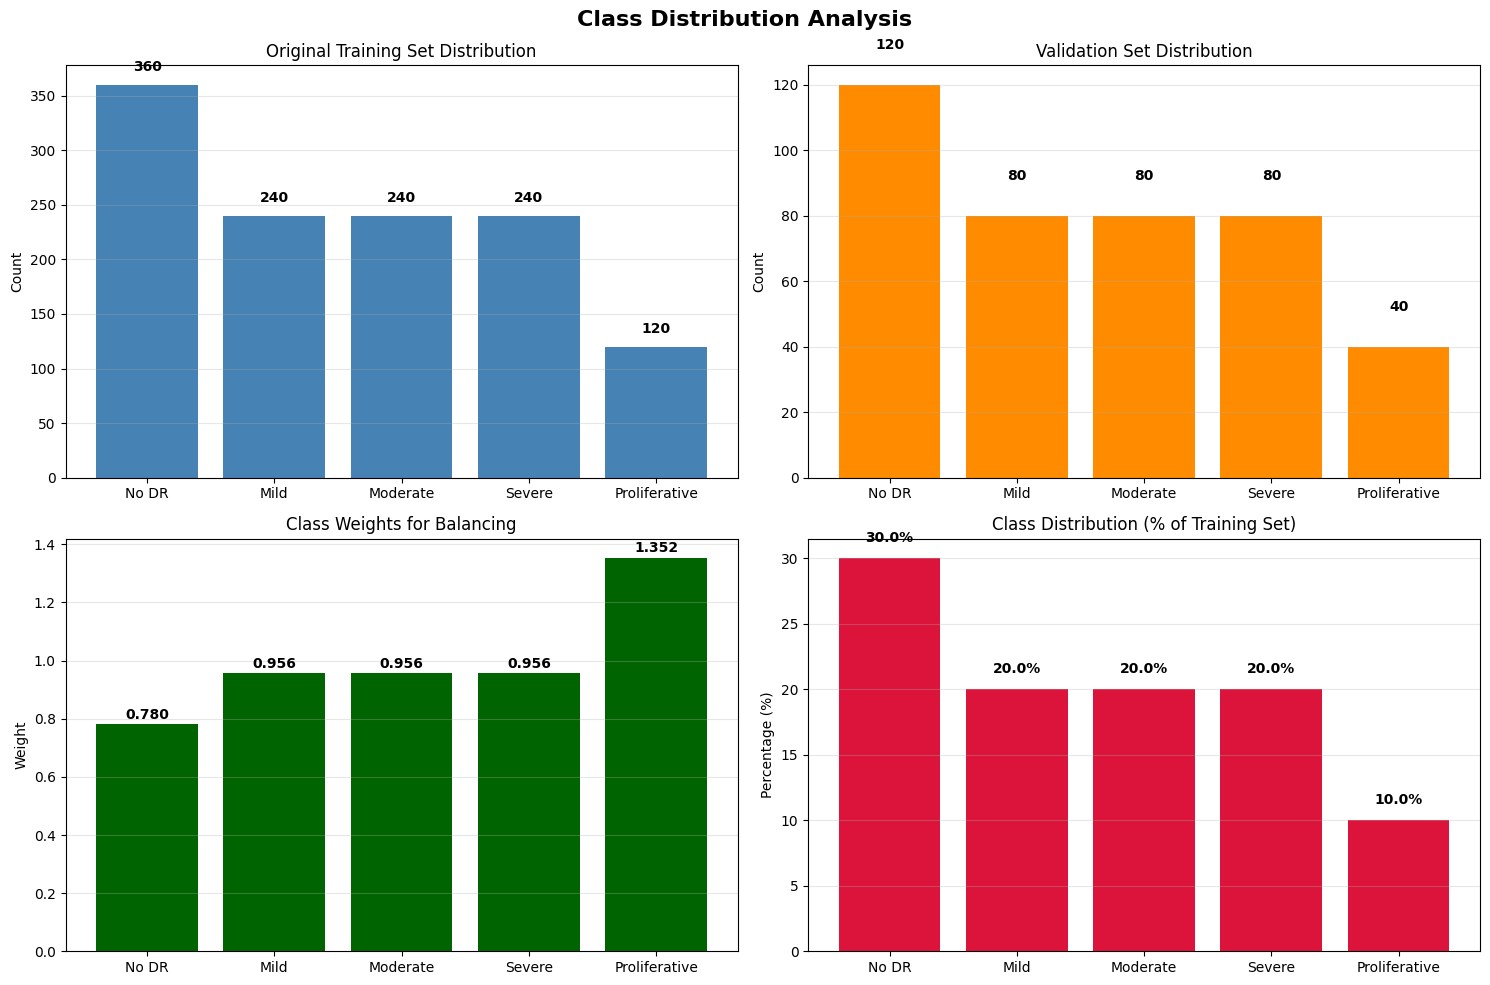


CLASS DISTRIBUTION STATISTICS

Training Set (1200 total):
  No DR          :   360 samples ( 30.0%) | Weight: 0.7805
  Mild           :   240 samples ( 20.0%) | Weight: 0.9559
  Moderate       :   240 samples ( 20.0%) | Weight: 0.9559
  Severe         :   240 samples ( 20.0%) | Weight: 0.9559
  Proliferative  :   120 samples ( 10.0%) | Weight: 1.3518

Validation Set (400 total):
  No DR          :   120 samples ( 30.0%)
  Mild           :    80 samples ( 20.0%)
  Moderate       :    80 samples ( 20.0%)
  Severe         :    80 samples ( 20.0%)
  Proliferative  :    40 samples ( 10.0%)

Test Set (400 total):
  No DR          :   200 samples ( 50.0%)
  Mild           :    36 samples (  9.0%)
  Moderate       :    72 samples ( 18.0%)
  Severe         :    72 samples ( 18.0%)
  Proliferative  :    20 samples (  5.0%)

Imbalance Ratio (max/min): 3.00

✓ Images cached! Training will now load from cache (10x faster).

Loading datasets from cache...
✓ Datasets loaded:
  - Train: 1200 images (

100%|██████████| 47.2M/47.2M [00:00<00:00, 97.7MB/s]


Total Parameters: 11,550,765
Trainable Parameters: 11,550,765


Starting Training: EfficientNet-B3 + EDL for DR Classification
Using Your Image Preprocessor



Epoch 1/100:   3%|▎         | 1/38 [01:25<52:53, 85.78s/it, loss=0.869, nll=0.869, kl=0]



⏳ Running final backup...

EXECUTING BACKUP TO GOOGLE DRIVE
✓ Backed up CSV: /content/drive/MyDrive/EyeShield/labels_backup.csv
✓ Backed up training script: /content/drive/MyDrive/EyeShield/training_script_backup.py
Backup timestamp: 2026-04-06 02:39:35

✓ All files backed up to Google Drive


KeyboardInterrupt: 

In [12]:
# Validate prerequisites before training
import os

print("="*80)
print("PRE-TRAINING VALIDATION")
print("="*80)

# Check 1: CSV exists and has data
csv_path = '/content/dataset/labels.csv'
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"❌ Dataset CSV not found: {csv_path}\n"
                           f"   Please run the 'Prepare Dataset CSV' cell first")

import pandas as pd
df = pd.read_csv(csv_path)
if len(df) == 0:
    raise ValueError(f"❌ Dataset CSV is empty: {csv_path}\n"
                    f"   The CSV was created but contains no images.")

print(f"✓ CSV exists with {len(df)} images")

# Check 2: Training script exists
script_path = '/content/eyeshield_training_preprocessor_deepdrid_modified.py'
if not os.path.exists(script_path):
    raise FileNotFoundError(f"❌ Training script not found: {script_path}\n"
                           f"   Please run the 'Modify Config and Run Training' cell first")
print(f"✓ Training script ready")

# Check 2b: image_processor module exists (required by training script)
image_processor_path = '/content/image_processor.py'
if not os.path.exists(image_processor_path) or os.path.getsize(image_processor_path) == 0:
    print("⚠ image_processor.py not found. Attempting to download...")
    from urllib.request import urlretrieve

    image_processor_url = "https://raw.githubusercontent.com/dondondon22/EyeShield/refs/heads/main/image_processor.py"
    try:
        urlretrieve(image_processor_url, image_processor_path)
    except Exception as e:
        raise FileNotFoundError(
            f"❌ Required module missing: {image_processor_path}\n"
            f"   Auto-download failed: {e}\n"
            f"   Please rerun the 'Copy Training Script' cell."
        )

if not os.path.exists(image_processor_path) or os.path.getsize(image_processor_path) == 0:
    raise FileNotFoundError(
        f"❌ Required module is still missing or empty: {image_processor_path}\n"
        f"   Please rerun the 'Copy Training Script' cell."
    )

print("✓ image_processor module ready")

# Check 3: Backup function exists
try:
    backup_all_files  # Test if function is defined
    print("✓ Backup function available")
except NameError:
    raise NameError("❌ Backup function not defined. Please run 'Backup' cell first")

print("="*80)
print("✓ All prerequisites satisfied. Starting training...\n")

# Execute the full training pipeline
%cd /content

import sys
if '/content' not in sys.path:
    sys.path.insert(0, '/content')

# Compatibility patch for older image_processor.py versions downloaded from GitHub
import importlib.util
import numpy as np

def patch_image_processor_module(module_path='/content/image_processor.py'):
    """Patch ImageCacheManager methods at runtime for backward compatibility."""
    if not os.path.exists(module_path):
        raise FileNotFoundError(f"image_processor.py not found at {module_path}")

    spec = importlib.util.spec_from_file_location('image_processor', module_path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)

    def _safe_get_cache_path(self, image_filename):
        safe_filename = str(image_filename).replace('/', '__').replace('\\', '__')
        return os.path.join(self.cache_dir, f"{safe_filename}.npy")

    def _legacy_get_cache_path(self, image_filename):
        return os.path.join(self.cache_dir, f"{image_filename}.npy")

    def _cache_exists(self, image_filename):
        return os.path.exists(_safe_get_cache_path(self, image_filename)) or os.path.exists(
            _legacy_get_cache_path(self, image_filename)
        )

    def _load_cached_image(self, image_filename):
        new_path = _safe_get_cache_path(self, image_filename)
        legacy_path = _legacy_get_cache_path(self, image_filename)

        if os.path.exists(new_path):
            img = np.load(new_path)
        elif os.path.exists(legacy_path):
            img = np.load(legacy_path)
        else:
            raise FileNotFoundError(
                f"Cached image not found in either format:\n"
                f"  - New: {new_path}\n"
                f"  - Legacy: {legacy_path}"
            )

        if img.dtype == np.uint8:
            return img.astype(np.float32) / 255.0
        return img.astype(np.float32)

    def _get_cache_size_gb(self):
        total_size = 0
        if os.path.exists(self.cache_dir):
            for root, _, files in os.walk(self.cache_dir):
                for file in files:
                    if file.endswith('.npy'):
                        file_path = os.path.join(root, file)
                        if os.path.isfile(file_path):
                            total_size += os.path.getsize(file_path)
        return total_size / (1024**3)

    # Patch class methods (safe even if already present)
    module.ImageCacheManager.get_cache_path = _safe_get_cache_path
    module.ImageCacheManager._get_legacy_cache_path = _legacy_get_cache_path
    module.ImageCacheManager.cache_exists = _cache_exists
    module.ImageCacheManager.load_cached_image = _load_cached_image
    module.ImageCacheManager._get_cache_size_gb = _get_cache_size_gb

    # Ensure training script import uses this patched module
    sys.modules['image_processor'] = module

patch_image_processor_module(image_processor_path)
print("✓ image_processor compatibility patch applied")

# Import all training components
print("Loading training script...")
try:
    # Read the modified training script
    with open('/content/eyeshield_training_preprocessor_deepdrid_modified.py', 'r') as f:
        training_script = f.read()

    # Create a namespace with all required modules
    import torch
    import numpy as np
    import matplotlib
    import matplotlib.pyplot as plt
    import seaborn
    from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import train_test_split
    import cv2
    from PIL import Image
    import pydicom
    from torch.utils.data import WeightedRandomSampler
    import kagglehub

    exec_namespace = {
        '__name__': '__main__',
        '__file__': '/content/eyeshield_training_preprocessor_deepdrid_modified.py',
        'torch': torch,
        'np': np,
        'plt': plt,
        'pd': pd,
        'cv2': cv2,
        'Image': Image,
        'pydicom': pydicom,
        'WeightedRandomSampler': WeightedRandomSampler,
        'train_test_split': train_test_split,
        'confusion_matrix': confusion_matrix,
        'classification_report': classification_report,
        'accuracy_score': accuracy_score,
        'f1_score': f1_score,
        'StandardScaler': StandardScaler,
        'kagglehub': kagglehub,
    }

    # Execute the script
    exec(training_script, exec_namespace)

    print("\n✓ Training completed!")

except FileNotFoundError as e:
    print(f"❌ File not found: {e}")
except Exception as e:
    print(f"❌ Error: {type(e).__name__}: {str(e)}")
    import traceback
    print("\nFull traceback:")
    traceback.print_exc()

finally:
    # Always backup on training completion or error
    print("\n⏳ Running final backup...")
    backup_all_files()
    print("✓ All files backed up to Google Drive")

# Resume Training

⚠️ **IMPORTANT:** Before running this section:
1. You **MUST** run the "Resume Training from Best Checkpoint" cell first to load the checkpoint
2. Only then run the "Resume TRAINING" cell below

If you skip the checkpoint loading cell, the training will fail with an error about undefined variables.

In [ ]:
# Resume Training from Best Checkpoint
import os
import glob
import torch

checkpoint_dir = '/content/drive/MyDrive/EyeShield/checkpoints'

print("="*80)
print("RESUME TRAINING FROM CHECKPOINT")
print("="*80)

# List available checkpoints
checkpoint_files = glob.glob(os.path.join(checkpoint_dir, '*.pt'))
checkpoint_files.sort(key=os.path.getmtime)

print(f"\n📁 Checkpoint directory: {checkpoint_dir}")
print(f"Found {len(checkpoint_files)} checkpoint(s):\n")

best_model_path = os.path.join(checkpoint_dir, 'best_model.pt')
if os.path.exists(best_model_path):
    # Get modification time
    import datetime
    mtime = os.path.getmtime(best_model_path)
    mtime_str = datetime.datetime.fromtimestamp(mtime).strftime('%Y-%m-%d %H:%M:%S')
    size_mb = os.path.getsize(best_model_path) / (1024**2)
    print(f"✓ best_model.pt (BEST) - Modified: {mtime_str}, Size: {size_mb:.2f}MB")

for cp in checkpoint_files:
    if 'best_model' not in cp:
        mtime = os.path.getmtime(cp)
        mtime_str = datetime.datetime.fromtimestamp(mtime).strftime('%Y-%m-%d %H:%M:%S')
        size_mb = os.path.getsize(cp) / (1024**2)
        print(f"  • {os.path.basename(cp)} - Modified: {mtime_str}, Size: {size_mb:.2f}MB")

# Load best model checkpoint with weights_only=False for PyTorch 2.6+ compatibility
print(f"\n⏳ Loading best_model.pt...")
try:
    checkpoint = torch.load(best_model_path, map_location='cpu', weights_only=False)

    print(f"✓ Checkpoint loaded successfully!")
    print(f"  - Trained for {checkpoint.get('epoch', 'unknown')} epochs")
    print(f"  - Validation metrics: {checkpoint.get('val_metrics', {})}")

    # Store checkpoint for use in training cell
    RESUME_CHECKPOINT = checkpoint
    RESUME_CHECKPOINT_PATH = best_model_path
    RESUME_FROM_EPOCH = checkpoint.get('epoch', 0) + 1

    print(f"\n✓ Ready to resume from epoch {RESUME_FROM_EPOCH}")
    print("  Run the training cell below to continue from this checkpoint")

except Exception as e:
    print(f"❌ Error loading checkpoint: {e}")
    print("\n💡 Troubleshooting:")
    print("   • Make sure checkpoint file exists at:", best_model_path)
    print("   • If using PyTorch 2.6+, weights_only parameter is used")
    print("   • Checkpoint must contain model_state, optimizer_state, and epoch keys")
    RESUME_CHECKPOINT = None

# Resume TRAINING

In [ ]:
# RESUME TRAINING from Checkpoint
# Make sure to run the previous cell first to load the checkpoint

%cd /content

if 'RESUME_CHECKPOINT' in locals() and RESUME_CHECKPOINT is not None:
    print("="*80)
    print("RESUMING TRAINING FROM CHECKPOINT")
    print("="*80)

    import sys
    sys.path.insert(0, '/content')

    try:
        # Create namespace with resume checkpoint
        exec_namespace = {
            '__name__': '__main__',
            '__file__': '/content/eyeshield_training_preprocessor_deepdrid_modified.py',
            'RESUME_CHECKPOINT': RESUME_CHECKPOINT,
        }

        # Read the training script
        with open('/content/eyeshield_training_preprocessor_deepdrid_modified.py', 'r') as f:
            training_code = f.read()

        # Inject helper function that will be called from the training script
        # This function wraps trainer.train() to load checkpoint first
        helper_code = '''
def _resume_wrapper_train(trainer, resume_checkpoint=None):
    """Wrapper to load checkpoint before training"""
    if resume_checkpoint is not None:
        print("\\n" + "="*80)
        print("LOADING CHECKPOINT FOR RESUME")
        print("="*80)
        try:
            resume_ckpt = resume_checkpoint
            trainer.model.load_state_dict(resume_ckpt['model_state'])
            trainer.optimizer.load_state_dict(resume_ckpt['optimizer_state'])
            resume_epoch = resume_ckpt.get('epoch', 0)
            print(f"✓ Checkpoint loaded from epoch {resume_epoch}")
            print(f"✓ Model weights and optimizer state restored")
            print(f"✓ Resuming training from epoch {resume_epoch + 1}")
            print("="*80 + "\\n")
        except Exception as e:
            print(f"⚠ Could not load checkpoint: {e}")

    # Call original train method
    trainer.train()

'''

        # Add the helper function to the namespace before executing
        exec(helper_code, exec_namespace)

        # Modify the training script to use the wrapper
        # Replace trainer.train() with _resume_wrapper_train(trainer, RESUME_CHECKPOINT)
        modified_code = training_code.replace(
            'trainer.train()',
            '_resume_wrapper_train(trainer, RESUME_CHECKPOINT)'
        )

        # Execute the modified script
        exec(modified_code, exec_namespace)

        print("\n✓ Training resumed and completed!")

    except FileNotFoundError as e:
        print(f"❌ File not found: {e}")
        print("   Make sure the 'Modify Config and Run Training' cell was executed first")
    except Exception as e:
        print(f"❌ Error: {type(e).__name__}: {str(e)}")
        import traceback
        print("\nFull traceback:")
        traceback.print_exc()

    finally:
        # Always backup on completion
        print("\n⏳ Running final backup...")
        backup_all_files()
        print("✓ All files backed up to Google Drive")

else:
    print("❌ No checkpoint loaded!")
    print("   Please run the 'Resume Training from Best Checkpoint' cell first to load a checkpoint")



In [ ]:
# Checkpoint Inspector (Optional - View Details Before Resuming)
import torch
import os
import json

checkpoint_path = '/content/drive/MyDrive/EyeShield/checkpoints/best_model.pt'

if os.path.exists(checkpoint_path):
    print("="*80)
    print("CHECKPOINT DETAILS")
    print("="*80)

    # Load with weights_only=False for PyTorch 2.6+ compatibility
    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)

    print(f"\n📋 Checkpoint Information:")
    print(f"   Path: {checkpoint_path}")
    print(f"   File size: {os.path.getsize(checkpoint_path) / (1024**2):.2f} MB")

    if 'epoch' in checkpoint:
        print(f"   Last trained epoch: {checkpoint['epoch']}")

    if 'val_metrics' in checkpoint:
        metrics = checkpoint['val_metrics']
        print(f"\n📊 Validation Metrics at last save:")
        for key, value in metrics.items():
            if isinstance(value, (int, float)):
                print(f"      {key}: {value:.4f}")

    if 'model_state' in checkpoint:
        model_size = sum(p.numel() for p in checkpoint['model_state'].values())
        print(f"\n🧠 Model:")
        print(f"      Total parameters: {model_size:,}")

    print(f"\n✓ This checkpoint is ready to resume from!")
    print(f"  Next epoch will be: {checkpoint.get('epoch', 0) + 1}")

else:
    print(f"❌ Checkpoint not found at: {checkpoint_path}")
    print("   Train a model first or check the path")

CHECKPOINT DETAILS

📋 Checkpoint Information:
   Path: /content/drive/MyDrive/EyeShield/checkpoints/best_model.pt
   File size: 51.14 MB
   Last trained epoch: 2

📊 Validation Metrics at last save:
      loss: 0.1908
      nll: 0.1276
      kl: 0.6318
      accuracy: 0.8614
      macro_f1: 0.6765
      ece: 0.2093

🧠 Model:
      Total parameters: 11,639,421

✓ This checkpoint is ready to resume from!
  Next epoch will be: 3


# Monitor Training (Optional)

In [ ]:
# Use tensorboard to monitor training in real-time

# %load_ext tensorboard
# %tensorboard --logdir /content/logs

# Download Results

In [ ]:
from google.colab import files

# Download best model
files.download('/content/drive/MyDrive/EyeShield/checkpoints/best_model.pt')

# Download training history plot
files.download('/content/drive/MyDrive/EyeShield/logs/training_history.png')

# Download all checkpoints as zip
!cd /content/drive/MyDrive/EyeShield && zip -r checkpoints.zip checkpoints/
files.download('/content/drive/MyDrive/EyeShield/checkpoints.zip')

print("✓ Results downloaded!")

# Evaluation and Testing

In [ ]:
# Load Model Definition and Classes for Evaluation (Safe - No Training)
import sys
import torch
import re

sys.path.insert(0, '/content')

# Import the training module to get model class and config
print("Loading model class from training script...")
print("⚠ Extracting only class definitions (no training will execute)")

try:
    # Read the training script
    with open('/content/eyeshield_training_preprocessor_deepdrid_modified.py', 'r') as f:
        training_code = f.read()

    # Find and extract only the class definitions
    # Extract everything before "if __name__" or "trainer = Trainer" to avoid running training
    cutoff_markers = ['if __name__', 'trainer = Trainer', '# Train the model', 'trainer.train()']
    cutoff_index = len(training_code)

    for marker in cutoff_markers:
        idx = training_code.find(marker)
        if idx != -1 and idx < cutoff_index:
            cutoff_index = idx

    # Keep only the definitions part
    definitions_only = training_code[:cutoff_index]

    # Create a safe namespace for execution (only classes/functions, no side effects)
    model_namespace = {
        '__name__': '__main__',
        'torch': torch,
        'nn': torch.nn,
        'np': __import__('numpy'),
        'pd': __import__('pandas'),
        'cv2': __import__('cv2'),
        'pydicom': __import__('pydicom'),
        'Image': __import__('PIL').Image,
        'transforms': __import__('torchvision.transforms', fromlist=['transforms']),
        'models': __import__('torchvision.models', fromlist=['models']),
    }

    # Execute only the class definitions (not the training code)
    exec(definitions_only, model_namespace)

    # Extract the model class and config
    EfficientNetB3EDL = model_namespace.get('EfficientNetB3EDL')
    Config = model_namespace.get('Config')

    if EfficientNetB3EDL:
        print("✓ EfficientNetB3EDL class loaded successfully")
    else:
        print("⚠ EfficientNetB3EDL class not found")

    if Config:
        print("✓ Config class loaded successfully")
    else:
        print("⚠ Config class not found")

    # Set device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"✓ Using device: {device}")
    print("\n✓ Ready for evaluation - NO TRAINING EXECUTED")

except Exception as e:
    print(f"❌ Error loading model class: {e}")
    import traceback
    traceback.print_exc()



Loading model class from training script...
⚠ Extracting only class definitions (no training will execute)
Device: cuda
CUDA Available: True
GPU: NVIDIA L4
✓ EfficientNetB3EDL class loaded successfully
✓ Config class loaded successfully
✓ Using device: cuda

✓ Ready for evaluation - NO TRAINING EXECUTED


In [ ]:
# Create Test DataLoader for Evaluation
# Reads the 'test' split written by Cell 11 (DeepDRiD Evaluation / Set-C).
import os
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import cv2
import numpy as np
from PIL import Image
from torchvision import transforms

print("=" * 80)
print("CREATING TEST DATALOADER (DeepDRiD Set-C / Evaluation)")
print("=" * 80)

try:
    csv_path = '/content/dataset/labels.csv'
    df_full  = pd.read_csv(csv_path)
    print(f"\n✓ Loaded labels.csv — {len(df_full)} total rows")
    print(f"  Split counts:\n{df_full['split'].value_counts().to_string()}")

    # ── Use the official 'test' split (DeepDRiD Set-C evaluation set) ────────
    if 'split' not in df_full.columns or (df_full['split'] == 'test').sum() == 0:
        raise RuntimeError(
            "No 'test' rows found in labels.csv.\n"
            "Re-run 'Prepare Dataset CSV' (Cell 11) so the Evaluation folder "
            "is included as split=test."
        )

    test_df = df_full[df_full['split'] == 'test'].reset_index(drop=True)
    print(f"\n✓ Test set (Set-C): {len(test_df)} images")
    print(f"  Class distribution:\n{test_df['diagnosis'].value_counts().sort_index().to_string()}")

    # ── Validate that image files exist on disk ───────────────────────────────
    # Cell 11 stores absolute paths, so no root-joining needed.
    exists_mask = test_df['image_path'].apply(os.path.exists)
    missing     = int((~exists_mask).sum())
    if missing:
        print(f"\n⚠ {missing} images not found on disk — dropping them")
    test_df = test_df[exists_mask].reset_index(drop=True)
    test_df['full_path'] = test_df['image_path']

    if len(test_df) == 0:
        raise RuntimeError(
            "No valid test images found after path validation.\n"
            "The Evaluation Set-C images may not be present in this Kaggle mirror, "
            "or Challenge1_labels.xlsx was missing — check Cell 11 output."
        )

    print(f"\n✓ Valid test images: {len(test_df)}")

    # ── Dataset ───────────────────────────────────────────────────────────────
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    class FundusImageDataset(Dataset):
        """Loads DeepDRiD images directly from disk (no cache needed for eval)."""

        def __init__(self, eval_df, transform=None):
            self.df        = eval_df
            self.transform = transform

        def __len__(self):
            return len(self.df)

        def __getitem__(self, idx):
            row       = self.df.iloc[idx]
            img_path  = row['full_path']
            label     = int(row['diagnosis'])

            img = cv2.imread(img_path)
            if img is None:
                raise FileNotFoundError(f"Failed to read image: {img_path}")

            # Match training preprocessing: resize to 512×512, normalize to [0,1]
            img = cv2.resize(img, (512, 512), interpolation=cv2.INTER_LANCZOS4)
            img = img.astype(np.float32) / 255.0

            pil = Image.fromarray((img * 255).astype(np.uint8))
            img_tensor = self.transform(pil) if self.transform is not None else \
                         torch.from_numpy(img).permute(2, 0, 1)

            return img_tensor, torch.tensor(label, dtype=torch.long)

    test_dataset = FundusImageDataset(test_df, transform=test_transform)

    pin_memory  = torch.cuda.is_available()
    test_loader = DataLoader(
        test_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=2,
        pin_memory=pin_memory,
    )

    sample_x, sample_y = test_dataset[0]
    EVAL_VALID_TEST_SIZE = len(test_df)

    print("\n✓ Test DataLoader ready")
    print(f"  Batches      : {len(test_loader)}")
    print(f"  Batch size   : 32")
    print(f"  Total samples: {EVAL_VALID_TEST_SIZE}")
    print(f"  Tensor shape : {tuple(sample_x.shape)}")
    print(f"  Sample label : {int(sample_y)}")
    print("\n✓ Ready for evaluation — run the next cell")

except Exception as e:
    print(f"❌ Error creating test loader: {e}")
    import traceback
    traceback.print_exc()


CREATING TEST DATALOADER (TRAINING-CONSISTENT TEST SPLIT)

✓ Loaded CSV with 92501 total rows
✓ Split config: seed=42, max_dataset_size=60000, test_ratio=0.15
⚠ Limiting dataset from 92501 -> 60000 using training logic
✓ Rows used for splitting: 59997
✓ Test split rows (pre-path-validation): 9000
  Test class distribution:
diagnosis
0    6709
1     451
2    1474
3     122
4     244
Name: count, dtype: int64
Using Colab cache for faster access to the 'eyepacs-aptos-messidor-diabetic-retinopathy' dataset.

Dataset root candidate coverage:
  - /kaggle/input/eyepacs-aptos-messidor-diabetic-retinopathy/dr_unified_v2/dr_unified_v2: 512/512 probe files found
  - /content/drive/MyDrive/EyeShield: 0/512 probe files found
  - /content/dataset: 0/512 probe files found
  - /kaggle/input/eyepacs-aptos-messidor-diabetic-retinopathy: 0/512 probe files found
  - /kaggle/input/eyepacs-aptos-messidor-diabetic-retinopathy/dr_unified_v2: 0/512 probe files found
✓ Resolved dataset root: /kaggle/input/eyepa

MODEL EVALUATION AND TESTING
NOTE: This cell is manual. If training was interrupted (e.g., during plot_training_history), run this cell explicitly.
Evaluation run started at: 2026-03-21 11:29:24

✓ Evaluation split metadata: target_test=9000, valid_test=9000

Checkpoint candidates:
  - best_model.pt -> macro_f1=0.6765 (metadata)
  - checkpoint_epoch_5_f1_0.4212.pt -> macro_f1=0.4212 (filename)
  - checkpoint_epoch_10_f1_0.4782.pt -> macro_f1=0.4782 (filename)
  - checkpoint_epoch_15_f1_0.5021.pt -> macro_f1=0.5021 (filename)
  - checkpoint_epoch_20_f1_0.5188.pt -> macro_f1=0.5188 (filename)
  - checkpoint_epoch_25_f1_0.5543.pt -> macro_f1=0.5543 (filename)
  - checkpoint_epoch_30_f1_0.5490.pt -> macro_f1=0.5490 (filename)
  - checkpoint_epoch_35_f1_0.5630.pt -> macro_f1=0.5630 (filename)
  - checkpoint_epoch_40_f1_0.5571.pt -> macro_f1=0.5571 (filename)
  - checkpoint_epoch_45_f1_0.5549.pt -> macro_f1=0.5549 (filename)
  - checkpoint_epoch_50_f1_0.5583.pt -> macro_f1=0.5583 (filename)


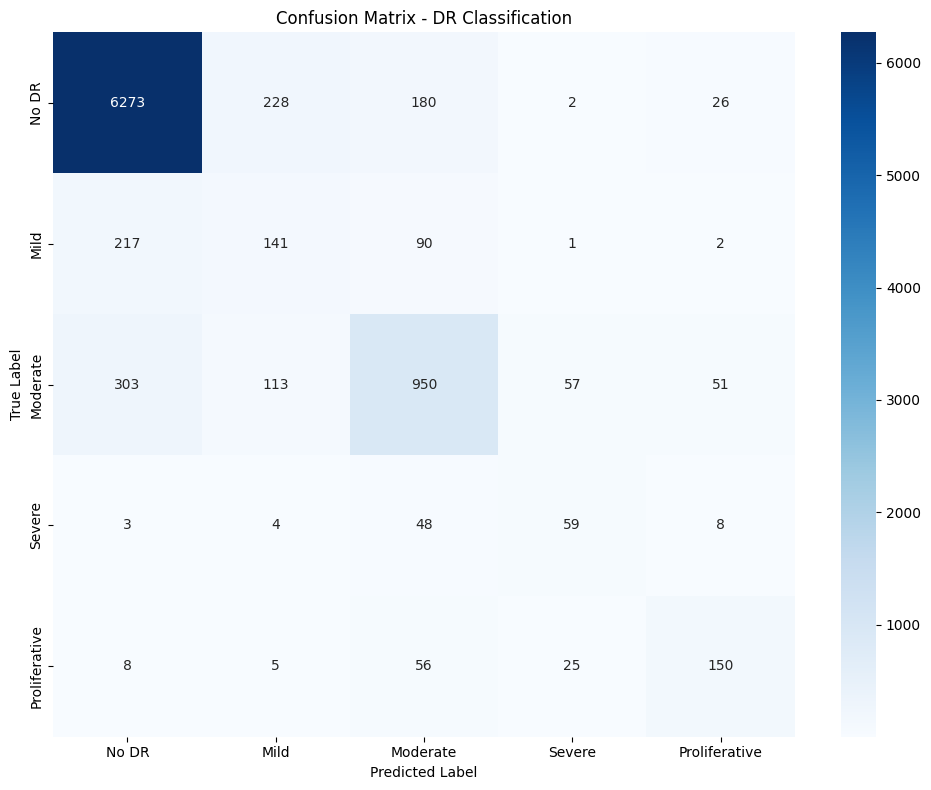


Classification Report:
               precision    recall  f1-score   support

        No DR     0.9220    0.9350    0.9284      6709
         Mild     0.2872    0.3126    0.2994       451
     Moderate     0.7175    0.6445    0.6791      1474
       Severe     0.4097    0.4836    0.4436       122
Proliferative     0.6329    0.6148    0.6237       244

     accuracy                         0.8414      9000
    macro avg     0.5939    0.5981    0.5948      9000
 weighted avg     0.8419    0.8414    0.8412      9000



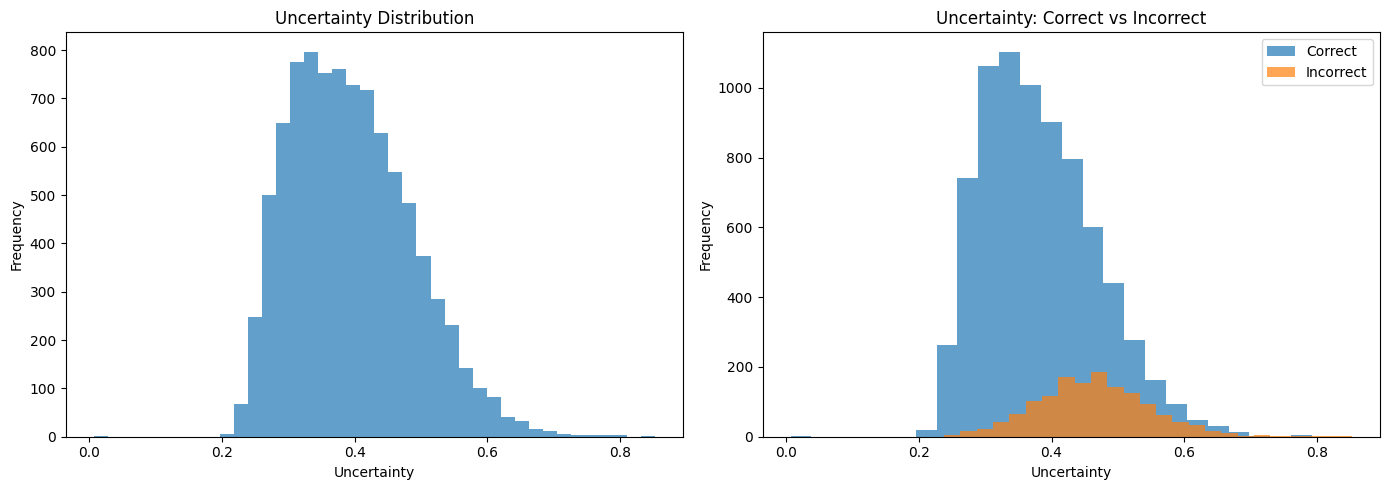


✓ Evaluation complete at 2026-03-21 11:36:18



In [ ]:
import os
import re
import glob
from datetime import datetime
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("=" * 80)
print("MODEL EVALUATION AND TESTING")
print("=" * 80)
print("NOTE: This cell is manual. If training was interrupted (e.g., during plot_training_history), run this cell explicitly.")
print(f"Evaluation run started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

class_names = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']
class_ids = [0, 1, 2, 3, 4]


def parse_f1_from_filename(path):
    """Parse F1 from checkpoint filename like checkpoint_epoch_50_f1_0.5703.pt."""
    m = re.search(r"_f1_([0-9]*\.?[0-9]+)\.pt$", os.path.basename(path))
    return float(m.group(1)) if m else -1.0


def choose_best_checkpoint(checkpoint_dir):
    """Choose checkpoint with highest available validation macro-F1."""
    best_model_path = os.path.join(checkpoint_dir, 'best_model.pt')
    named_ckpts = glob.glob(os.path.join(checkpoint_dir, 'checkpoint_epoch_*_f1_*.pt'))

    candidate_paths = []
    if os.path.exists(best_model_path):
        candidate_paths.append(best_model_path)
    candidate_paths.extend(named_ckpts)

    if not candidate_paths:
        raise FileNotFoundError(f"No checkpoint files found in {checkpoint_dir}")

    best_path = None
    best_score = -1.0

    print("\nCheckpoint candidates:")
    for path in candidate_paths:
        score = parse_f1_from_filename(path)
        src = 'filename'

        # Try metadata score when available (more reliable than filename)
        try:
            ckpt = torch.load(path, map_location='cpu', weights_only=False)
            if 'val_metrics' in ckpt and isinstance(ckpt['val_metrics'], dict) and 'macro_f1' in ckpt['val_metrics']:
                score = float(ckpt['val_metrics']['macro_f1'])
                src = 'metadata'
        except Exception:
            pass

        print(f"  - {os.path.basename(path)} -> macro_f1={score:.4f} ({src})")

        if score > best_score:
            best_score = score
            best_path = path

    return best_path, best_score


# Verify prerequisites
if 'EfficientNetB3EDL' not in locals():
    print("⚠ Model class not loaded. Run 'Load Model Definition and Classes for Evaluation' first")
elif 'test_loader' not in locals():
    print("⚠ test_loader not found. Run 'Create Test DataLoader for Evaluation' first")
else:
    try:
        if 'EVAL_TEST_SPLIT_SIZE' in globals() and 'EVAL_VALID_TEST_SIZE' in globals():
            print(f"\n✓ Evaluation split metadata: target_test={EVAL_TEST_SPLIT_SIZE}, valid_test={EVAL_VALID_TEST_SIZE}")
        else:
            print("\n⚠ Split metadata not found. Re-run the previous DataLoader cell to ensure correct test split.")

        checkpoint_dir = '/content/drive/MyDrive/EyeShield/checkpoints'
        checkpoint_path, selected_score = choose_best_checkpoint(checkpoint_dir)

        print("\n✓ Loading selected checkpoint...")
        checkpoint = torch.load(checkpoint_path, weights_only=False)

        model = EfficientNetB3EDL(num_classes=5, pretrained=False)
        model.load_state_dict(checkpoint['model_state'])
        model.to(device)
        model.eval()

        print("✓ Model loaded successfully")
        print(f"  - Checkpoint path: {checkpoint_path}")
        print(f"  - Selected macro F1 score: {selected_score:.4f}")
        print(f"  - Checkpoint epoch: {checkpoint.get('epoch', 'unknown')}")
        print(f"  - Model parameters: {sum(p.numel() for p in model.parameters()):,}")
        if 'val_metrics' in checkpoint and isinstance(checkpoint['val_metrics'], dict):
            vm = checkpoint['val_metrics']
            if 'macro_f1' in vm:
                print(f"  - Checkpoint val macro F1: {vm['macro_f1']:.4f}")
            if 'accuracy' in vm:
                print(f"  - Checkpoint val accuracy: {vm['accuracy']:.4f}")

        print("\nRunning evaluation on test set...")
        all_preds = []
        all_targets = []
        all_uncertainties = []

        with torch.no_grad():
            for images, targets in test_loader:
                images = images.to(device, non_blocking=True)
                targets = targets.to(device, non_blocking=True)

                evidence = model(images)
                output = model.predict(evidence)

                all_preds.extend(output['pred'].cpu().numpy().tolist())
                all_targets.extend(targets.cpu().numpy().tolist())
                all_uncertainties.extend(output['uncertainty'].cpu().numpy().reshape(-1).tolist())

        all_preds = np.array(all_preds, dtype=np.int64)
        all_targets = np.array(all_targets, dtype=np.int64)
        all_uncertainties = np.array(all_uncertainties, dtype=np.float32)

        print(f"✓ Evaluated samples: {len(all_targets)}")

        # Distribution diagnostics
        true_counts = np.bincount(all_targets, minlength=5)
        pred_counts = np.bincount(all_preds, minlength=5)

        print("\nClass distribution (true vs predicted):")
        for cid, cname in enumerate(class_names):
            print(f"  {cname:<13} true={true_counts[cid]:5d}  pred={pred_counts[cid]:5d}")

        unique_pred = np.unique(all_preds)
        if len(unique_pred) == 1:
            print(f"\n⚠ Prediction collapse detected: model predicted only class {int(unique_pred[0])} ({class_names[int(unique_pred[0])]})")
            print("  This usually indicates dataset/path/preprocessing mismatch during evaluation.")

        # Confusion matrix with fixed class axes
        cm = confusion_matrix(all_targets, all_preds, labels=class_ids)

        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            ax=ax,
            xticklabels=class_names,
            yticklabels=class_names,
        )
        ax.set_title('Confusion Matrix - DR Classification')
        ax.set_ylabel('True Label')
        ax.set_xlabel('Predicted Label')
        plt.tight_layout()
        plt.savefig('/content/drive/MyDrive/EyeShield/logs/confusion_matrix.png', dpi=300)
        plt.show()

        # Classification report with fixed labels
        print("\nClassification Report:")
        print(
            classification_report(
                all_targets,
                all_preds,
                labels=class_ids,
                target_names=class_names,
                digits=4,
                zero_division=0,
            )
        )

        # Uncertainty plots (downsample if very large to keep plotting responsive)
        max_points = 20000
        if len(all_uncertainties) > max_points:
            rng = np.random.default_rng(42)
            idx = rng.choice(len(all_uncertainties), size=max_points, replace=False)
            unc_plot = all_uncertainties[idx]
            preds_plot = all_preds[idx]
            targets_plot = all_targets[idx]
            print(f"\n⚠ Downsampled uncertainty plots to {max_points} points for responsiveness")
        else:
            unc_plot = all_uncertainties
            preds_plot = all_preds
            targets_plot = all_targets

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].hist(unc_plot, bins=40, alpha=0.7)
        axes[0].set_title('Uncertainty Distribution')
        axes[0].set_xlabel('Uncertainty')
        axes[0].set_ylabel('Frequency')

        correct_mask = preds_plot == targets_plot
        correct_unc = unc_plot[correct_mask]
        incorrect_unc = unc_plot[~correct_mask]

        axes[1].hist(correct_unc, bins=25, alpha=0.7, label='Correct')
        axes[1].hist(incorrect_unc, bins=25, alpha=0.7, label='Incorrect')
        axes[1].set_title('Uncertainty: Correct vs Incorrect')
        axes[1].set_xlabel('Uncertainty')
        axes[1].set_ylabel('Frequency')
        axes[1].legend()

        plt.tight_layout()
        plt.savefig('/content/drive/MyDrive/EyeShield/logs/uncertainty_analysis.png', dpi=300)
        plt.show()

        EVALUATION_LAST_RUN_AT = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        print(f"\n✓ Evaluation complete at {EVALUATION_LAST_RUN_AT}")

    except FileNotFoundError as e:
        print(f"❌ File not found: {e}")
        print('   Make sure checkpoints have been saved during training')
    except Exception as e:
        print(f"❌ Error: {type(e).__name__}: {str(e)}")
        import traceback
        traceback.print_exc()

print("\n" + "=" * 80)

# Temperature Scaling and Uncertainty Rejection

POST-TRAINING CALIBRATION + REJECTION PIPELINE
⚠ val_loader not found; using test_loader for calibration

Step 1: Collecting validation evidence...
✓ Collected 9000 calibration samples

Step 2: Optimizing temperature...
✓ Optimal temperature: T = 1.3168
  → Model was mildly overconfident — beliefs slightly softened

Step 3: Wrapping model with optimal temperature...
✓ Calibrated model saved

Step 4: Comparing ECE before vs after calibration...

  Before Calibration:
    Accuracy  : 0.8414
    Macro F1  : 0.5948
    ECE       : 0.1938
    Unc range : 0.006 – 0.853
    Unc mean  : 0.3953

  After Calibration:
    Accuracy  : 0.8414
    Macro F1  : 0.5948
    ECE       : 0.2410
    Unc range : 0.008 – 0.884
    Unc mean  : 0.4602

Step 5: Finding optimal rejection threshold...

Threshold    Accept%    Reject%    Accuracy     Macro F1     Note
--------------------------------------------------------------------
0.30         1.4        98.6       0.9758       0.4968       
0.35         11.9

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (10,) and arg 1 with shape (8,).

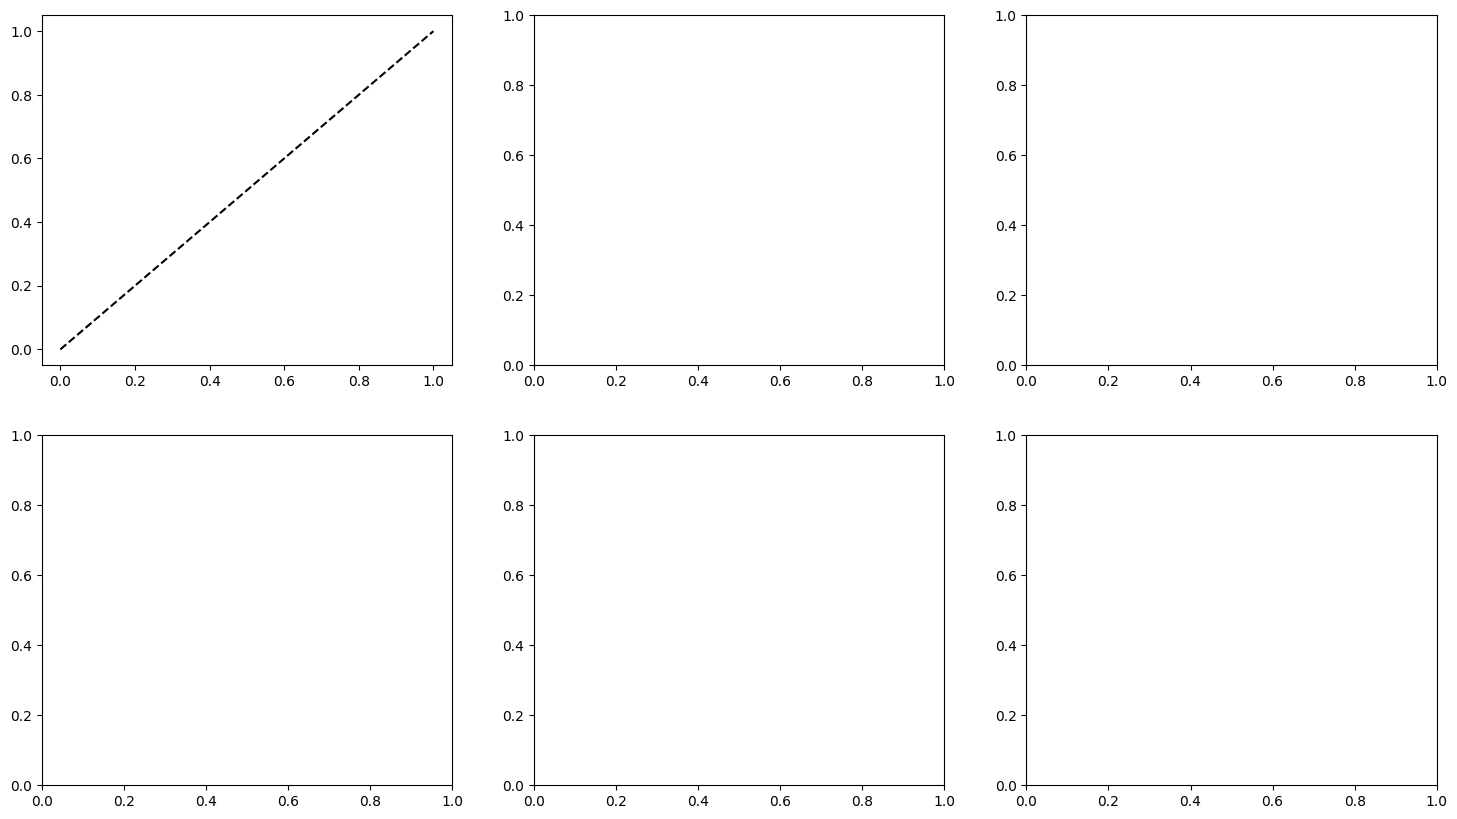

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from torch.optim import LBFGS
from sklearn.metrics import f1_score, accuracy_score
import matplotlib.pyplot as plt

print("="*60)
print("POST-TRAINING CALIBRATION + REJECTION PIPELINE")
print("="*60)

# Ensure required runtime objects exist
if 'model' not in globals() or model is None:
    raise NameError(
        "model is not defined. Run the model evaluation loading cell first "
        "(the one that loads checkpoint into `model`)."
    )

if 'device' not in globals() or device is None:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Resolve calibration loader
if 'val_loader' in globals() and val_loader is not None:
    calibration_loader = val_loader
    print("✓ Using val_loader for calibration")
elif 'test_loader' in globals() and test_loader is not None:
    calibration_loader = test_loader
    val_loader = test_loader  # Backward compatibility for downstream code
    print("⚠ val_loader not found; using test_loader for calibration")
else:
    raise NameError(
        "Neither val_loader nor test_loader is defined. "
        "Run the 'Create Test DataLoader for Evaluation' cell first."
    )

if len(calibration_loader) == 0:
    raise RuntimeError("Calibration loader is empty. Recreate the evaluation DataLoader.")


# ── TEMPERATURE SCALING CLASS ─────────────────────────────────
class TemperatureScaler(nn.Module):
    """Wraps trained EDL model with learnable temperature parameter."""

    def __init__(self, model):
        super().__init__()
        self.model = model
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, x):
        evidence = self.model(x)
        return evidence / self.temperature

    def predict(self, evidence):
        return self.model.predict(evidence)


# ── STEP 1: COLLECT VAL EVIDENCE ─────────────────────────────
print("\nStep 1: Collecting validation evidence...")
model.eval()

all_evidence, all_labels = [], []

with torch.no_grad():
    for images, labels in calibration_loader:
        images = images.to(device)
        evidence = model(images)
        all_evidence.append(evidence.cpu())
        all_labels.append(labels)

all_evidence = torch.cat(all_evidence).to(device)
all_labels   = torch.cat(all_labels).to(device)
print(f"✓ Collected {len(all_labels)} calibration samples")


# ── STEP 2: FIND OPTIMAL TEMPERATURE ─────────────────────────
print("\nStep 2: Optimizing temperature...")

temperature = nn.Parameter(torch.ones(1).to(device) * 1.5)
optimizer   = LBFGS([temperature], lr=0.01, max_iter=200)
criterion   = nn.CrossEntropyLoss()

def eval_step():
    optimizer.zero_grad()
    scaled_evidence = all_evidence / temperature
    alpha   = scaled_evidence + 1
    S       = alpha.sum(dim=1, keepdim=True)
    belief  = alpha / S
    loss    = criterion(belief, all_labels)
    loss.backward()
    return loss

optimizer.step(eval_step)

optimal_T = temperature.item()
print(f"✓ Optimal temperature: T = {optimal_T:.4f}")

if optimal_T > 2.0:
    print("  → Model was very overconfident — temperature softened beliefs significantly")
elif optimal_T > 1.0:
    print("  → Model was mildly overconfident — beliefs slightly softened")
else:
    print("  → Model was underconfident — beliefs sharpened")


# ── STEP 3: WRAP MODEL WITH TEMPERATURE ──────────────────────
print("\nStep 3: Wrapping model with optimal temperature...")
calibrated_model = TemperatureScaler(model)
calibrated_model.temperature = nn.Parameter(
    torch.tensor([optimal_T])
)
calibrated_model = calibrated_model.to(device)
calibrated_model.eval()

# Save calibrated model
torch.save({
    'model_state':  model.state_dict(),
    'temperature':  optimal_T,
    'base_f1':      float(checkpoint.get('val_metrics', {}).get('macro_f1', -1)),
    'base_epoch':   int(checkpoint.get('epoch', -1))
}, '/content/drive/MyDrive/EyeShield/checkpoints/calibrated_model.pt')
print("✓ Calibrated model saved")


# ── STEP 4: COMPARE BEFORE vs AFTER ──────────────────────────
print("\nStep 4: Comparing ECE before vs after calibration...")

def compute_ece_and_metrics(mdl, loader, device, label):
    mdl.eval()
    all_preds, all_targets = [], []
    all_uncertainties, all_beliefs = [], []

    with torch.no_grad():
        for images, labels in loader:
            images  = images.to(device)
            evidence = mdl(images)
            output   = mdl.predict(evidence)

            all_preds.extend(output['pred'].cpu().numpy())
            all_targets.extend(labels.numpy())
            all_uncertainties.extend(
                output['uncertainty'].view(-1).cpu().numpy()
            )
            all_beliefs.extend(output['belief'].cpu().numpy())

    preds        = np.array(all_preds)
    targets      = np.array(all_targets)
    uncertainties = np.array(all_uncertainties)
    beliefs      = np.array(all_beliefs)
    confidences  = beliefs.max(axis=1)

    # ECE
    n_bins = 10
    bins   = np.linspace(0, 1, n_bins + 1)
    ece    = 0.0
    for i in range(n_bins):
        mask = (confidences >= bins[i]) & (confidences < bins[i+1])
        if mask.sum() > 0:
            ece += (np.abs(confidences[mask].mean() -
                           (preds[mask] == targets[mask]).mean()) *
                    mask.sum() / len(targets))

    acc = accuracy_score(targets, preds)
    f1  = f1_score(targets, preds, average='macro', zero_division=0)

    print(f"\n  {label}:")
    print(f"    Accuracy  : {acc:.4f}")
    print(f"    Macro F1  : {f1:.4f}")
    print(f"    ECE       : {ece:.4f}")
    print(f"    Unc range : {uncertainties.min():.3f} – "
          f"{uncertainties.max():.3f}")
    print(f"    Unc mean  : {uncertainties.mean():.4f}")

    return preds, targets, uncertainties, beliefs

# Before calibration
preds_raw, targets, unc_raw, beliefs_raw = compute_ece_and_metrics(
    model, calibration_loader, device, 'Before Calibration'
)
# After calibration
preds_cal, _,       unc_cal, beliefs_cal = compute_ece_and_metrics(
    calibrated_model, calibration_loader, device, 'After Calibration'
)


# ── STEP 5: FIND OPTIMAL REJECTION THRESHOLD ─────────────────
print("\n" + "="*60)
print("Step 5: Finding optimal rejection threshold...")
print("="*60)

thresholds = np.arange(0.10, 1.01, 0.05)

print(f"\n{'Threshold':<12} {'Accept%':<10} {'Reject%':<10} "
      f"{'Accuracy':<12} {'Macro F1':<12} {'Note'}")
print("-" * 68)

best_t   = None
best_f1  = 0.0
results  = []

for t in thresholds:
    accepted = unc_cal < t
    if accepted.sum() < 10:
        continue

    rej_rate = (~accepted).mean() * 100
    acc = accuracy_score(targets[accepted], preds_cal[accepted])
    f1  = f1_score(targets[accepted], preds_cal[accepted],
                   average='macro', zero_division=0)

    note = ''
    if rej_rate <= 30 and f1 > best_f1:
        best_f1 = f1
        best_t  = t
        note    = '← BEST'

    results.append({
        'threshold':    t,
        'accepted':     accepted.sum(),
        'rejection_rate': rej_rate,
        'accuracy':     acc,
        'macro_f1':     f1
    })

    print(f"{t:<12.2f} {100-rej_rate:<10.1f} {rej_rate:<10.1f} "
          f"{acc:<12.4f} {f1:<12.4f} {note}")

print(f"\n✓ Optimal threshold : {best_t:.2f}")
print(f"  Macro F1 accepted : {best_f1:.4f}")


# ── STEP 6: PLOT EVERYTHING ───────────────────────────────────
print("\nStep 6: Plotting calibration and rejection curves...")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Reliability diagram — before
conf_raw = beliefs_raw.max(axis=1)
bins_plot = np.linspace(0, 1, 11)
bin_accs_raw, bin_confs_raw = [], []
for i in range(10):
    mask = (conf_raw >= bins_plot[i]) & (conf_raw < bins_plot[i+1])
    if mask.sum() > 0:
        bin_accs_raw.append((preds_raw[mask] == targets[mask]).mean())
        bin_confs_raw.append(conf_raw[mask].mean())

axes[0,0].plot([0,1], [0,1], 'k--', label='Perfect calibration')
axes[0,0].bar(bins_plot[:-1], bin_accs_raw, width=0.1,
              align='edge', alpha=0.7, label='Model')
axes[0,0].set_title('Reliability Diagram — Before Calibration')
axes[0,0].set_xlabel('Confidence')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].legend()

# Reliability diagram — after
conf_cal = beliefs_cal.max(axis=1)
bin_accs_cal, bin_confs_cal = [], []
for i in range(10):
    mask = (conf_cal >= bins_plot[i]) & (conf_cal < bins_plot[i+1])
    if mask.sum() > 0:
        bin_accs_cal.append((preds_cal[mask] == targets[mask]).mean())
        bin_confs_cal.append(conf_cal[mask].mean())

axes[0,1].plot([0,1], [0,1], 'k--', label='Perfect calibration')
axes[0,1].bar(bins_plot[:-1], bin_accs_cal, width=0.1,
              align='edge', alpha=0.7, color='orange', label='Model')
axes[0,1].set_title('Reliability Diagram — After Calibration')
axes[0,1].set_xlabel('Confidence')
axes[0,1].legend()

# Uncertainty distribution — before vs after
axes[0,2].hist(unc_raw, bins=50, alpha=0.6, label='Before', color='blue')
axes[0,2].hist(unc_cal, bins=50, alpha=0.6, label='After',  color='orange')
axes[0,2].set_title('Uncertainty Distribution')
axes[0,2].set_xlabel('Uncertainty')
axes[0,2].legend()

# F1 vs threshold
axes[1,0].plot([r['threshold'] for r in results],
               [r['macro_f1']  for r in results], 'g-o')
axes[1,0].axvline(best_t, color='red', linestyle='--',
                  label=f'Optimal T={best_t:.2f}')
axes[1,0].set_title('Macro F1 vs Rejection Threshold')
axes[1,0].set_xlabel('Uncertainty Threshold')
axes[1,0].set_ylabel('Macro F1 on Accepted')
axes[1,0].legend()
axes[1,0].grid(True)

# Rejection rate vs threshold
axes[1,1].plot([r['threshold']     for r in results],
               [r['rejection_rate'] for r in results], 'r-o')
axes[1,1].axvline(best_t, color='red', linestyle='--',
                  label=f'Optimal T={best_t:.2f}')
axes[1,1].set_title('Rejection Rate vs Threshold')
axes[1,1].set_xlabel('Uncertainty Threshold')
axes[1,1].set_ylabel('% Rejected')
axes[1,1].legend()
axes[1,1].grid(True)

# Correct vs incorrect uncertainty
correct_mask = preds_cal == targets
axes[1,2].hist(unc_cal[correct_mask],  bins=40, alpha=0.7,
               label=f'Correct ({correct_mask.sum()})',   color='green')
axes[1,2].hist(unc_cal[~correct_mask], bins=40, alpha=0.7,
               label=f'Incorrect ({(~correct_mask).sum()})', color='red')
axes[1,2].axvline(best_t, color='black', linestyle='--',
                  label=f'Threshold={best_t:.2f}')
axes[1,2].set_title('Uncertainty: Correct vs Incorrect')
axes[1,2].set_xlabel('Uncertainty')
axes[1,2].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/EyeShield/logs/calibration_rejection.png',
            dpi=300)
plt.show()
print("✓ Plots saved")
print(f"\n{'='*60}")
print(f"FINAL MODEL SUMMARY")
print(f"{'='*60}")
print(f"  Temperature     : {optimal_T:.4f}")
print(f"  Optimal threshold: {best_t:.2f}")
print(f"  Best F1 accepted : {best_f1:.4f}")
print(f"  Calibrated model : calibrated_model.pt")